Actual party distribution after spatial assignment:
  Party 0: 1131 voters (45.2%)
  Party 1: 750 voters (30.0%)
  Party 2: 619 voters (24.8%)
  Run 100/100 complete


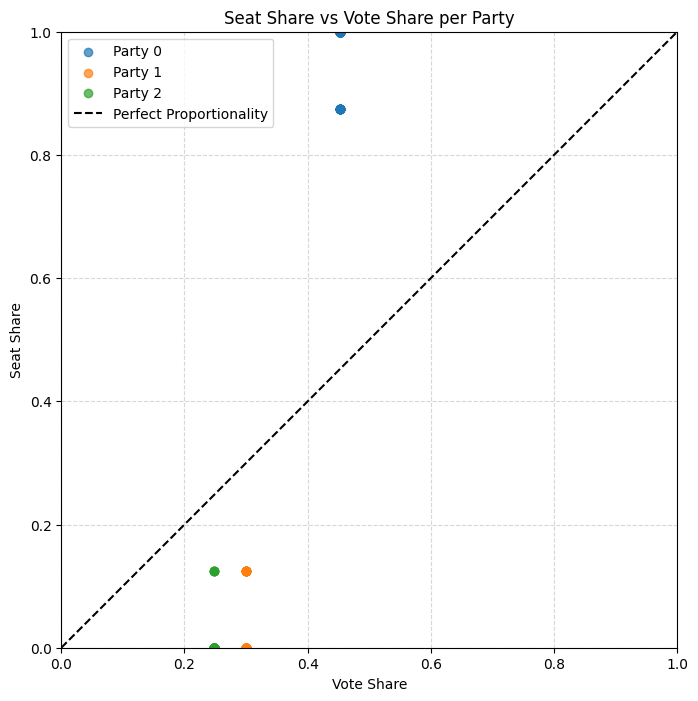


----- REDISTRICTING SUMMARY -----
Runs: 100
Party 0: Mean Vote Share = 0.452, Mean Seat Share = 0.976
Party 1: Mean Vote Share = 0.300, Mean Seat Share = 0.018
Party 2: Mean Vote Share = 0.248, Mean Seat Share = 0.006


In [271]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from collections import deque
import itertools
import pandas as pd

# ============================================================
# PARAMETERS
# ============================================================
WIDTH = 380
HEIGHT = 280
NUM_VOTERS = 2500
NUM_PARTIES = 3
NUM_DISTRICTS = 8
VOTERS_PER_DISTRICT = NUM_VOTERS // NUM_DISTRICTS
NUM_RUNS = 100

NUM_CITIES = 6
CITY_INTENSITY = (15, 40)
CITY_SPREAD = (15, 35)

# Spatial autocorrelation parameters for party assignment
SPATIAL_K_NEIGHBORS = 15
SPATIAL_INFLUENCE = 0.85
SPATIAL_ITERATIONS = 20

np.random.seed(1)

PARTY_IDS = [f"Party {i}" for i in range(NUM_PARTIES)]
party_colors = np.random.rand(NUM_PARTIES, 3)
PARTY_COLORS = dict(zip(PARTY_IDS, party_colors))

# Party distribution bias — must sum to 1
# Must update when changing NUM_PARTIES
PARTY_BIAS = [0.45,0.3,.25]

# ============================================================
# GENERATE POPULATION DENSITY
# ============================================================
density = np.full((HEIGHT, WIDTH), 1.0)
X, Y = np.meshgrid(np.arange(WIDTH), np.arange(HEIGHT))

for _ in range(NUM_CITIES):
    cx = np.random.uniform(0, WIDTH)
    cy = np.random.uniform(0, HEIGHT)
    intensity = np.random.uniform(*CITY_INTENSITY)
    sigma = np.random.uniform(*CITY_SPREAD)
    density += intensity * np.exp(-((X - cx)**2 + (Y - cy)**2) / (2 * sigma**2))

# ============================================================
# GENERATE VOTERS BASED ON DENSITY
# ============================================================
flat_density = density.ravel()
flat_density /= flat_density.sum()
indices = np.random.choice(WIDTH * HEIGHT, size=NUM_VOTERS, p=flat_density)
voters_y, voters_x = np.unravel_index(indices, (HEIGHT, WIDTH))
voters = np.column_stack((voters_x, voters_y))

# ============================================================
# SPATIALLY CORRELATED PARTY PREFERENCES
# ============================================================

def assign_parties_with_spatial_correlation(voters, num_parties, party_bias,
                                             k_neighbors=15, influence=0.85,
                                             iterations=20):
    """
    Assigns party preferences with spatial autocorrelation.
    Voters near each other tend to share party preferences, creating
    geographic clusters rather than uniform random assignment.
    """
    N = len(voters)
    tree = cKDTree(voters)
    _, neighbor_indices = tree.query(voters, k=k_neighbors)

    # Start with random assignment based on base bias
    parties = np.random.choice(np.arange(num_parties), size=N, p=party_bias)

    # Iteratively update based on neighbors to create geographic clusters
    for _ in range(iterations):
        new_parties = parties.copy()
        for i in range(N):
            neighbors = neighbor_indices[i]
            neighbor_counts = np.bincount(parties[neighbors], minlength=num_parties)
            neighbor_probs = neighbor_counts / neighbor_counts.sum()
            blended_probs = (1 - influence) * np.array(party_bias) + influence * neighbor_probs
            blended_probs /= blended_probs.sum()
            new_parties[i] = np.random.choice(num_parties, p=blended_probs)
        parties = new_parties

    return parties


# Assign spatially correlated party preferences — fixed for entire simulation
voter_parties = assign_parties_with_spatial_correlation(
    voters, NUM_PARTIES, PARTY_BIAS,
    k_neighbors=SPATIAL_K_NEIGHBORS,
    influence=SPATIAL_INFLUENCE,
    iterations=SPATIAL_ITERATIONS
)
voter_colors = party_colors[voter_parties]

# Print actual party distribution after spatial assignment
unique, counts = np.unique(voter_parties, return_counts=True)
print("Actual party distribution after spatial assignment:")
for p, c in zip(unique, counts):
    print(f"  Party {p}: {c} voters ({100*c/NUM_VOTERS:.1f}%)")


# ============================================================
# ADJACENCY GRAPH (kNN)
# Built once and frozen — defines all legal expansion moves
# ============================================================

def build_adjacency(voters, k=40):
    """Builds a kNN adjacency graph for all voters."""
    tree = cKDTree(voters)
    adjacency = {}
    for i in range(len(voters)):
        _, idx = tree.query(voters[i], k=k + 1)
        adjacency[i] = set(idx[1:])
    return adjacency

adjacency = build_adjacency(voters, k=40)


# ============================================================
# SEED SELECTION
# ============================================================

def pick_seeds(n_nodes, num_districts, rng, voters, min_dist=40):
    """
    Selects well-separated seed voters for district growth.
    Enforces minimum spatial distance between seeds.
    """
    seeds = []
    attempts = 0
    max_attempts = n_nodes * 10

    while len(seeds) < num_districts and attempts < max_attempts:
        candidate = rng.integers(n_nodes)
        attempts += 1

        if not seeds:
            seeds.append(candidate)
            continue

        seed_coords = voters[seeds]
        candidate_coord = voters[candidate]
        dists = np.linalg.norm(seed_coords - candidate_coord, axis=1)

        if dists.min() >= min_dist:
            seeds.append(candidate)

    # Fill remainder randomly if not enough seeds found with spacing
    if len(seeds) < num_districts:
        remaining = [i for i in range(n_nodes) if i not in seeds]
        rng.shuffle(remaining)
        seeds += remaining[:num_districts - len(seeds)]

    return np.array(seeds)


# ============================================================
# CONNECTED DISTRICT GROWTH (BFS)
# ============================================================

def grow_district(seed, adjacency, assigned, max_size, rng,
                  voter_parties=None, target_party=None, bias_strength=0.0):
    """
    Grows a district from a seed using BFS along adjacency edges.
    Optionally biases growth toward a target party.
    """
    district = set([seed])
    queue = deque([seed])
    visited = set([seed])

    while queue and len(district) < max_size:
        node = queue.popleft()
        neighbors = list(adjacency[node])

        if target_party is not None and bias_strength > 0:
            def score(nbr):
                is_target = (voter_parties[nbr] == target_party)
                return bias_strength * is_target + (1 - bias_strength) * rng.random()
            neighbors = sorted(neighbors, key=score, reverse=True)
        else:
            rng.shuffle(neighbors)

        for nbr in neighbors:
            if nbr not in visited and not assigned[nbr]:
                visited.add(nbr)
                district.add(nbr)
                queue.append(nbr)
                if len(district) >= max_size:
                    break

    for n in district:
        assigned[n] = True

    return district


# ============================================================
# LEFTOVER ASSIGNMENT
# ============================================================

def assign_leftovers(districts, assigned, adjacency, labels, rng, max_iter=50):
    """
    Assigns unassigned voters to adjacent districts using iterative
    flood-fill. Enforces contiguity — voters can only join districts
    they are spatially touching.
    """
    unassigned = [i for i in range(len(assigned)) if not assigned[i]]

    for _ in range(max_iter):
        if not unassigned:
            break

        still_unassigned = []

        for node in unassigned:
            assigned_neighbors = [nbr for nbr in adjacency[node] if assigned[nbr]]

            if assigned_neighbors:
                neighbor_labels = [labels[nbr] for nbr in assigned_neighbors]
                chosen = max(set(neighbor_labels), key=neighbor_labels.count)
                districts[chosen].add(node)
                labels[node] = chosen
                assigned[node] = True
            else:
                still_unassigned.append(node)

        unassigned = still_unassigned

    # Safety net for any remaining unassigned voters
    if unassigned:
        assigned_indices = np.where(assigned)[0]
        assigned_tree = cKDTree(voters[assigned_indices])
        for node in unassigned:
            _, idx = assigned_tree.query(voters[node])
            chosen = labels[assigned_indices[idx]]
            districts[chosen].add(node)
            labels[node] = chosen
            assigned[node] = True

    return districts, labels


# ============================================================
# MAIN DISTRICTING FUNCTION
# ============================================================

def connected_districts(voters, adjacency, num_districts, rng,
                        voter_parties, target_size=None, tolerance=0.15,
                        target_party=None, bias_strength=0.0):
    """
    Builds geographically connected districts using BFS from well-separated
    seeds. Enforces population balance within tolerance via rebalancing pass.
    Optionally biases growth toward a target party.
    """
    n = len(voters)
    if target_size is None:
        target_size = n // num_districts

    seeds = pick_seeds(n, num_districts, rng, voters, min_dist=40)

    assigned = np.zeros(n, dtype=bool)
    labels = np.full(n, -1, dtype=int)
    districts = []

    for seed in seeds:
        # If seed was absorbed by an earlier district, find nearest unassigned
        if assigned[seed]:
            unassigned_pool = np.where(~assigned)[0]
            if len(unassigned_pool) == 0:
                break
            dists = np.linalg.norm(voters[unassigned_pool] - voters[seed], axis=1)
            seed = unassigned_pool[np.argmin(dists)]

        district = grow_district(
            seed, adjacency, assigned, target_size, rng,
            voter_parties=voter_parties,
            target_party=target_party,
            bias_strength=bias_strength
        )
        d_id = len(districts)
        districts.append(district)
        for node in district:
            labels[node] = d_id

    # Fix disconnected leftovers with iterative adjacency flood-fill
    districts, labels = assign_leftovers(
        districts, assigned, adjacency, labels, rng
    )

    # ── Population balance enforcement (±tolerance) ──
   # ── Population balance enforcement (±tolerance) ──
    min_size = int(target_size * (1 - tolerance))
    max_size = int(target_size * (1 + tolerance))

    for _ in range(200):
        sizes = np.bincount(labels, minlength=len(districts))
        over = [d for d in range(len(districts)) if sizes[d] > max_size]
        under = [d for d in range(len(districts)) if sizes[d] < min_size]

        if not over and not under:
            break

        for over_d in over:
            for node in list(districts[over_d]):
                if sizes[over_d] <= max_size:
                    break
                for nbr in adjacency[node]:
                    nbr_d = labels[nbr]
                    if nbr_d != over_d and sizes[nbr_d] < max_size:
                        # ── NEW: check connectivity before accepting move ──
                        districts[over_d].discard(node)
                        labels[node] = nbr_d

                        # Verify over_d is still connected after removal
                        members = list(districts[over_d])
                        if len(members) > 1:
                            member_set = set(members)
                            visited = set()
                            queue = [members[0]]
                            visited.add(members[0])
                            while queue:
                                cur = queue.pop(0)
                                for nb in adjacency[cur]:
                                    if nb in member_set and nb not in visited:
                                        visited.add(nb)
                                        queue.append(nb)
                            if len(visited) != len(members):
                                # Revert — move disconnects district
                                districts[over_d].add(node)
                                labels[node] = over_d
                                continue

                        districts[nbr_d].add(node)
                        sizes[over_d] -= 1
                        sizes[nbr_d] += 1
                        break
    return labels


# ============================================================
# VOTE COUNTING
# ============================================================

def count_votes(district_labels):
    """Returns a list of vote count dicts, one per district."""
    district_counts = []
    for d in range(NUM_DISTRICTS):
        mask = district_labels == d
        counts = {party: 0 for party in PARTY_IDS}
        for i in np.where(mask)[0]:
            counts[PARTY_IDS[voter_parties[i]]] += 1
        district_counts.append(counts)
    return district_counts


# ============================================================
# EFFICIENCY GAP
# ============================================================

def efficiency_gap(district_counts):
    """Returns a per-district efficiency gap value (multi-party generalization)."""
    district_gaps = []
    for district in district_counts:
        winning_party = max(district.items(), key=lambda item: item[1])[0]
        num_winning_votes = district[winning_party]
        total_votes = sum(district.values())
        num_losing_votes = total_votes - num_winning_votes
        wasted_winner = num_winning_votes - (total_votes / NUM_PARTIES)
        wasted_loser = num_losing_votes
        gap = (wasted_winner - wasted_loser) / total_votes
        district_gaps.append(gap)
    return district_gaps


# ============================================================
# SEAT-VOTE CURVE HELPERS
# ============================================================

def get_is_winner(district_counts, target_party):
    """Returns True if target_party strictly leads all others."""
    target_votes = district_counts[target_party]
    other_votes = [district_counts[p] for p in district_counts if p != target_party]
    return all(target_votes > v for v in other_votes)


def get_current_vote_share(district_counts, target_party):
    """Returns the statewide vote share of the target party."""
    total = sum(sum(d.values()) for d in district_counts)
    party_total = sum(d[target_party] for d in district_counts)
    return party_total / total


def simulate_vote_shifts_forward(district_counts, target_party, PARTY_IDS, NUM_DISTRICTS):
    """
    Shifts votes toward target_party by taking from the weakest competitor
    in each district, one step at a time.
    """
    counts = [d.copy() for d in district_counts]
    competitors = [p for p in PARTY_IDS if p != target_party]
    num_competitors = len(competitors)

    def count_wins():
        return sum(1 for d in counts if get_is_winner(d, target_party))

    current_wins = count_wins()
    history = []

    while True:
        any_shift = False
        for d in counts:
            active_competitors = sorted(
                [p for p in competitors if d[p] > 0],
                key=lambda p: (d[p], p)
            )
            if active_competitors:
                from_party = active_competitors[0]
                actual_taken = min(d[from_party], num_competitors)
                if actual_taken > 0:
                    d[from_party] -= actual_taken
                    d[target_party] += actual_taken
                    any_shift = True

        new_wins = count_wins()
        if new_wins > current_wins:
            vote_share = sum(d[target_party] for d in counts) / sum(sum(d.values()) for d in counts)
            history.append({"districts_won": new_wins, "vote_share": vote_share})
            current_wins = new_wins

        if not any_shift or new_wins == NUM_DISTRICTS:
            break

    return {"history": history, "initial_wins": count_wins(), "initial_vote_share": 0}


def simulate_vote_shifts_backward(district_counts, target_party, PARTY_IDS):
    """
    Shifts votes away from target_party toward the strongest competitor
    in each district, one step at a time.
    """
    counts = [d.copy() for d in district_counts]
    competitors = [p for p in PARTY_IDS if p != target_party]
    num_competitors = len(competitors)

    def count_wins():
        return sum(1 for d in counts if get_is_winner(d, target_party))

    current_wins = count_wins()
    history = []

    while True:
        any_shift = False
        for d in counts:
            ranked_competitors = sorted(
                competitors,
                key=lambda p: (d[p], p),
                reverse=True
            )
            strongest_competitor = ranked_competitors[0]
            to_move = min(d[target_party], num_competitors)
            if to_move > 0:
                d[target_party] -= to_move
                d[strongest_competitor] += to_move
                any_shift = True

        new_wins = count_wins()
        if new_wins < current_wins:
            vote_share = sum(d[target_party] for d in counts) / sum(sum(d.values()) for d in counts)
            history.append({"districts_won": new_wins, "vote_share": vote_share})
            current_wins = new_wins

        if not any_shift or new_wins == 0:
            break

    return {"history": history, "initial_wins": count_wins(), "initial_vote_share": 0}


def compute_step_curve_for_party(district_counts, target_party, PARTY_IDS, NUM_DISTRICTS):
    """
    Builds the full seat-vote step curve for a given party by merging
    forward and backward vote shift histories.
    """
    initial_vote = get_current_vote_share(district_counts, target_party)
    initial_wins = sum(1 for d in district_counts if get_is_winner(d, target_party))

    fwd = simulate_vote_shifts_forward(district_counts, target_party, PARTY_IDS, NUM_DISTRICTS)
    rev = simulate_vote_shifts_backward(district_counts, target_party, PARTY_IDS)

    base_point = (initial_vote, initial_wins)
    fwd_points = [base_point] + [(h["vote_share"], h["districts_won"]) for h in fwd["history"]]
    rev_points = [base_point] + [(h["vote_share"], h["districts_won"]) for h in rev["history"]]

    merged = sorted(set(fwd_points + rev_points))
    return merged


# ============================================================
# AREA METRICS
# ============================================================

def compute_step_function_area(step_points, num_districts):
    """
    Computes the geometric area between the seat-vote curve and its complement.
    Returns dict with keys: area_between, area_step, area_complement
    """
    points = sorted(step_points, key=lambda x: x[0])

    if points[0][0] > 0:
        points = [(0, 0)] + points
    if points[-1][0] < 1.0:
        points = points + [(1.0, points[-1][1])]

    step_x, step_y = zip(*points)
    step_x = np.array(step_x)
    step_y = np.array(step_y) / num_districts

    complement_x = 1 - step_x[::-1]
    complement_y = 1 - step_y[::-1]
    all_x = np.unique(np.concatenate([step_x, complement_x]))

    area_between = 0.0
    area_step = 0.0
    area_complement = 0.0

    def step_value_at(x, xs, ys):
        idx = np.searchsorted(xs, x, side='right') - 1
        return ys[max(0, idx)]

    for i in range(len(all_x) - 1):
        x1, x2 = all_x[i], all_x[i + 1]
        width = x2 - x1
        midpoint = (x1 + x2) / 2
        f_val = step_value_at(midpoint, step_x, step_y)
        g_val = step_value_at(midpoint, complement_x, complement_y)
        area_between += width * abs(f_val - g_val)
        area_step += width * f_val
        area_complement += width * g_val

    return {
        "area_between": area_between,
        "area_step": area_step,
        "area_complement": area_complement
    }


def compute_pairwise_area(curve1, curve2, num_districts):
    """
    Computes the absolute area between the step curves of two parties.
    Integral of |f(x) - g(x)| dx over [0, 1].
    """
    x1, y1 = zip(*sorted(curve1))
    x2, y2 = zip(*sorted(curve2))
    y1 = np.array(y1) / num_districts
    y2 = np.array(y2) / num_districts

    all_x = np.unique(np.concatenate([x1, x2]))
    if all_x[0] > 0:
        all_x = np.insert(all_x, 0, 0.0)
    if all_x[-1] < 1:
        all_x = np.append(all_x, 1.0)

    def get_val(x, xs, ys):
        idx = np.searchsorted(xs, x, side='right') - 1
        return ys[max(0, idx)]

    total_area = 0.0
    for i in range(len(all_x) - 1):
        mid = (all_x[i] + all_x[i+1]) / 2
        width = all_x[i+1] - all_x[i]
        diff = abs(get_val(mid, x1, y1) - get_val(mid, x2, y2))
        total_area += width * diff

    return total_area


# ============================================================
# EXCEL EXPORT
# ============================================================

def export_full_simulation_data(all_district_counts, all_step_curves, PARTY_IDS,
                                 filename="gerrymandering_data.xlsx"):
    """
    Exports simulation results to Excel with four sheets:
      - District_Details, Pairwise_Areas, Efficiency_Gaps, Summary
    """
    print(f"Gathering data for {len(all_district_counts)} runs...")

    dist_rows = []
    for run_idx, run_counts in enumerate(all_district_counts):
        for dist_idx, counts in enumerate(run_counts):
            winner = max(counts, key=counts.get)
            row = {"Run": run_idx + 1, "District": dist_idx + 1, "Winner": winner}
            for party in PARTY_IDS:
                row[f"{party}_Votes"] = counts[party]
            dist_rows.append(row)
    df_districts = pd.DataFrame(dist_rows)

    pair_rows = []
    party_pairs = list(itertools.combinations(PARTY_IDS, 2))
    for run_idx in range(len(all_step_curves)):
        current_curves = all_step_curves[run_idx]
        for p1, p2 in party_pairs:
            gap = compute_pairwise_area(current_curves[p1], current_curves[p2], NUM_DISTRICTS)
            pair_rows.append({"Run": run_idx + 1, "Comparison": f"{p1} vs {p2}", "Area_Gap": gap})
    df_areas = pd.DataFrame(pair_rows)

    gap_rows = []
    for run_idx, district_counts in enumerate(all_district_counts):
        wasted_votes = {p: 0 for p in PARTY_IDS}
        total_v = 0
        for d in district_counts:
            d_total = sum(d.values())
            total_v += d_total
            sorted_v = sorted(d.values(), reverse=True)
            winner_p = max(d, key=d.get)
            needed = sorted_v[1] + 1 if len(sorted_v) > 1 else (d_total // 2) + 1
            for p in PARTY_IDS:
                wasted_votes[p] += (max(0, d[p] - needed) if p == winner_p else d[p])
        for p in PARTY_IDS:
            others = sum(v for k, v in wasted_votes.items() if k != p)
            gap_rows.append({
                "Run": run_idx + 1,
                "Party": p,
                "Eff_Gap": (wasted_votes[p] - others) / total_v
            })
    df_eff = pd.DataFrame(gap_rows)

    with pd.ExcelWriter(filename, engine='openpyxl') as writer:
        df_districts.to_excel(writer, sheet_name='District_Details', index=False)
        df_areas.to_excel(writer, sheet_name='Pairwise_Areas', index=False)
        df_eff.to_excel(writer, sheet_name='Efficiency_Gaps', index=False)
        summary = df_areas.groupby("Comparison")["Area_Gap"].agg(['mean', 'std']).reset_index()
        summary.to_excel(writer, sheet_name='Summary', index=False)

    print(f"Export Complete: {filename}")


# ============================================================
# MAIN SIMULATION
# ============================================================

all_efficiency_gaps = []
all_pr_vote_shares = []
all_pr_seat_shares = []
all_district_counts = []
all_area_results = []
all_step_curves = []
all_starting_labels = []

for run in range(NUM_RUNS):
    rng = np.random.default_rng()

    district_labels = connected_districts(
        voters, adjacency, NUM_DISTRICTS, rng,
        voter_parties=voter_parties
    )
    all_starting_labels.append(district_labels.copy())

    district_counts = count_votes(district_labels)

    # Efficiency gap
    gap = efficiency_gap(district_counts)
    all_efficiency_gaps.append(gap)

    # Proportional representation — all parties
    pr_vote_share = {party: 0 for party in PARTY_IDS}
    pr_seat_share = {party: 0 for party in PARTY_IDS}

    for d in district_counts:
        for party in PARTY_IDS:
            pr_vote_share[party] += d[party]

    total_votes = sum(pr_vote_share.values())
    for party in PARTY_IDS:
        pr_vote_share[party] /= total_votes

    for d in district_counts:
        winner = max(d, key=d.get)
        pr_seat_share[winner] += 1
    for party in PARTY_IDS:
        pr_seat_share[party] /= NUM_DISTRICTS

    all_pr_vote_shares.append(pr_vote_share)
    all_pr_seat_shares.append(pr_seat_share)
    all_district_counts.append(district_counts)

    # Step curves for each party
    step_curves_this_run = {}
    area_results_this_run = {}

    for party in PARTY_IDS:
        curve = compute_step_curve_for_party(
            district_counts, party, PARTY_IDS, NUM_DISTRICTS
        )
        step_curves_this_run[party] = curve
        area_results_this_run[party] = compute_step_function_area(curve, NUM_DISTRICTS)

    all_step_curves.append(step_curves_this_run)
    all_area_results.append(area_results_this_run)

    if (run + 1) % 100 == 0:
        print(f"  Run {run+1}/{NUM_RUNS} complete")


# ============================================================
# SCATTER PLOT: Vote Share vs Seat Share
# ============================================================

plt.figure(figsize=(8, 8))
for party in PARTY_IDS:
    vote_shares = [run[party] for run in all_pr_vote_shares]
    seat_shares = [run[party] for run in all_pr_seat_shares]
    plt.scatter(vote_shares, seat_shares, alpha=0.7, label=party)

plt.plot([0, 1], [0, 1], linestyle='--', color='black', label='Perfect Proportionality')
plt.xlabel("Vote Share")
plt.ylabel("Seat Share")
plt.title("Seat Share vs Vote Share per Party")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.gca().set_aspect('equal', adjustable='box')
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


# ============================================================
# SUMMARY
# ============================================================

print("\n----- REDISTRICTING SUMMARY -----")
print("Runs:", NUM_RUNS)
if NUM_PARTIES == 2:
    print("Mean Efficiency Gap:", np.nanmean(all_efficiency_gaps))
    print("Std Efficiency Gap:", np.nanstd(all_efficiency_gaps))
for party in PARTY_IDS:
    mean_vote = np.mean([run[party] for run in all_pr_vote_shares])
    mean_seat = np.mean([run[party] for run in all_pr_seat_shares])
    print(f"{party}: Mean Vote Share = {mean_vote:.3f}, Mean Seat Share = {mean_seat:.3f}")

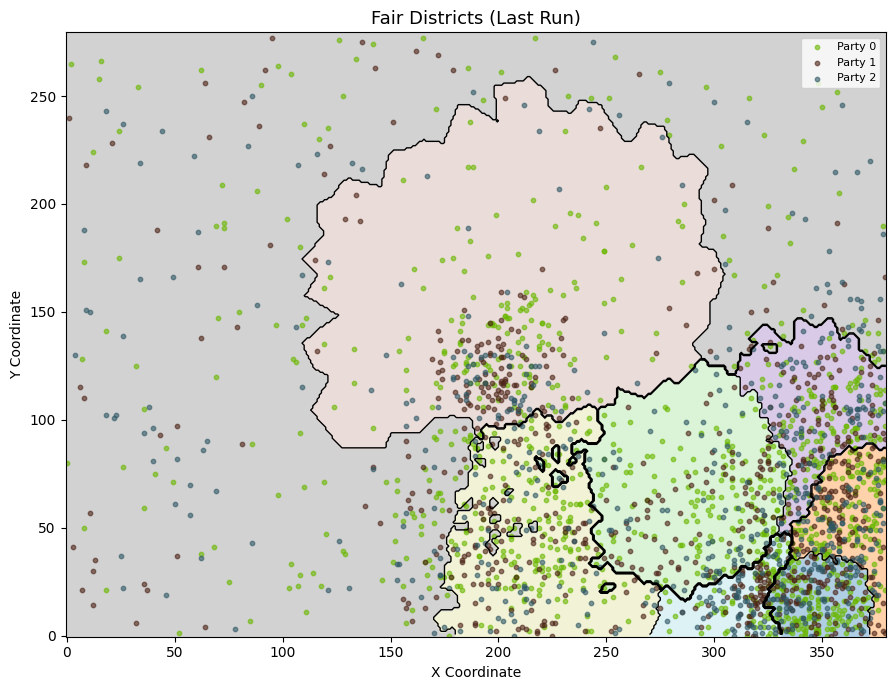

In [272]:
def plot_districts(district_labels, voter_parties, voters, title):
    tree = cKDTree(voters)
    xx, yy = np.meshgrid(np.arange(WIDTH), np.arange(HEIGHT))
    grid_points = np.column_stack((xx.ravel(), yy.ravel()))
    _, nearest_voter = tree.query(grid_points)
    pixel_map = district_labels[nearest_voter].reshape((HEIGHT, WIDTH))

    plt.figure(figsize=(10, 7))
    plt.imshow(pixel_map, origin='lower', cmap='tab20', alpha=0.35)
    plt.contour(pixel_map, levels=np.arange(NUM_DISTRICTS) + 0.5,
                colors='black', linewidths=1, origin='lower')
    for i, party in enumerate(PARTY_IDS):
        mask = voter_parties == i
        plt.scatter(voters[mask, 0], voters[mask, 1],
                    color=PARTY_COLORS[party], label=party, s=10, alpha=0.6)
    plt.title(title, fontsize=13)
    plt.xlabel("X Coordinate")
    plt.ylabel("Y Coordinate")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()



# ── Plot last fair run ──
plot_districts(all_starting_labels[-1], voter_parties, voters,
               "Fair Districts (Last Run)")

In [273]:
# ------------------------------------------------------------
# RUN PAIRWISE SIMULATIONS
# ------------------------------------------------------------
pairwise_results = []
party_pairs = list(itertools.combinations(PARTY_IDS, 2))

for run_idx in range(NUM_RUNS):
    # (Assuming district_counts and curves are generated here as in your main code)
    # Get all party curves for this run
    current_curves = all_step_curves[run_idx] 
    
    for p1, p2 in party_pairs:
        area_gap = compute_pairwise_area(current_curves[p1], current_curves[p2], NUM_DISTRICTS)
        
        pairwise_results.append({
            "Run": run_idx + 1,
            "Comparison": f"{p1} vs {p2}",
            "Area Gap": area_gap
        })

df_pairs = pd.DataFrame(pairwise_results)
print("\n--- PAIRWISE AREA DIFFERENCES ---")
print(df_pairs.head(20).to_string(index=False))



--- PAIRWISE AREA DIFFERENCES ---
 Run         Comparison  Area Gap
   1 Party 0 vs Party 1   0.06070
   1 Party 0 vs Party 2   0.06765
   1 Party 1 vs Party 2   0.02875
   2 Party 0 vs Party 1   0.07420
   2 Party 0 vs Party 2   0.06900
   2 Party 1 vs Party 2   0.02950
   3 Party 0 vs Party 1   0.06030
   3 Party 0 vs Party 2   0.05980
   3 Party 1 vs Party 2   0.01040
   4 Party 0 vs Party 1   0.05215
   4 Party 0 vs Party 2   0.06515
   4 Party 1 vs Party 2   0.02760
   5 Party 0 vs Party 1   0.06120
   5 Party 0 vs Party 2   0.06210
   5 Party 1 vs Party 2   0.01010
   6 Party 0 vs Party 1   0.05785
   6 Party 0 vs Party 2   0.05905
   6 Party 1 vs Party 2   0.03110
   7 Party 0 vs Party 1   0.05755
   7 Party 0 vs Party 2   0.06600


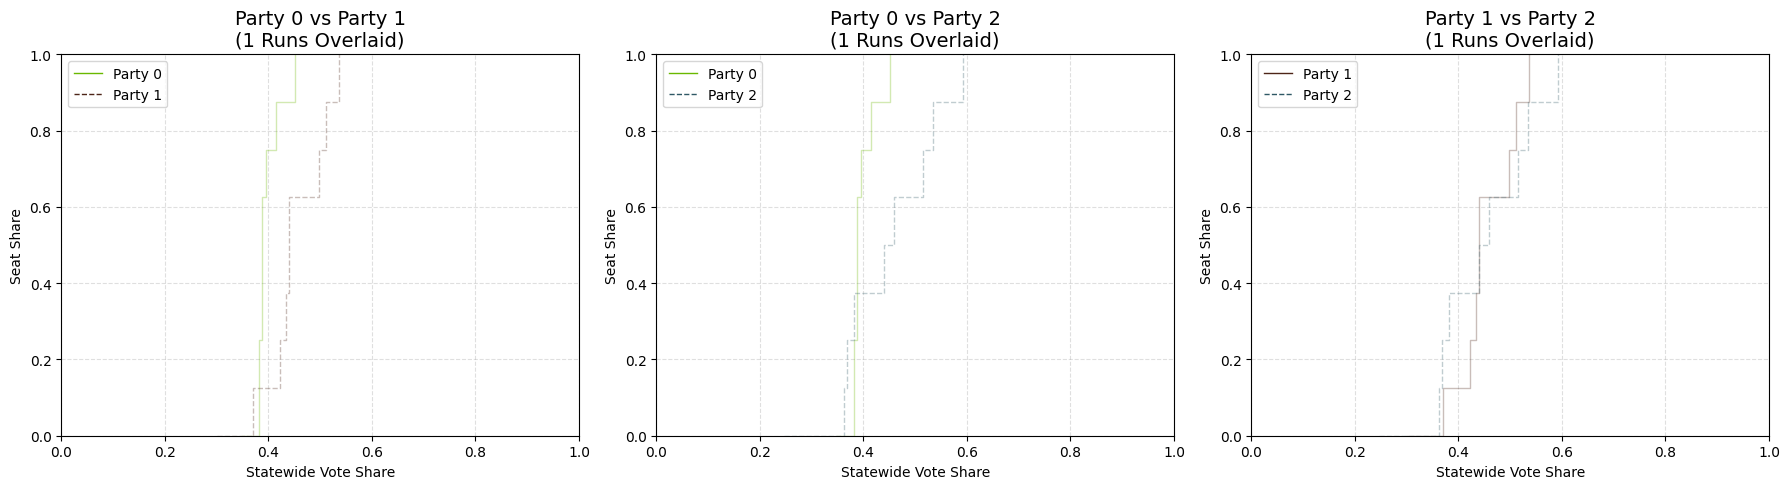

In [274]:
import itertools
import matplotlib.pyplot as plt
import numpy as np

def plot_pairwise_overlays(all_step_curves, PARTY_IDS, num_runs_to_plot=20):
    """
    Creates one graph for each unique party pair.
    Each graph overlays multiple simulation runs to show the variance in bias.
    """
    party_pairs = list(itertools.combinations(PARTY_IDS, 2))
    num_pairs = len(party_pairs)
    
    # Create a grid: 1 row, N columns (one for each pair)
    fig, axes = plt.subplots(1, num_pairs, figsize=(6 * num_pairs, 5), squeeze=False)
    
    # Determine how many runs to overlay
    runs_to_show = min(num_runs_to_plot, len(all_step_curves))

    for pair_idx, (party_a, party_b) in enumerate(party_pairs):
        ax = axes[0, pair_idx]
        
        for run_idx in range(runs_to_show):
            # Extract curves
            curve_a = all_step_curves[run_idx][party_a]
            curve_b = all_step_curves[run_idx][party_b]
            
            xa, ya = zip(*sorted(curve_a))
            xb, yb = zip(*sorted(curve_b))
            
            # Normalize to Seat Share
            ya_norm = np.array(ya) / NUM_DISTRICTS
            yb_norm = np.array(yb) / NUM_DISTRICTS
            
            # Use alpha (transparency) to handle the "overlay" effect
            # Only add a label for the first run so the legend isn't huge
            label_a = party_a if run_idx == 0 else None
            label_b = party_b if run_idx == 0 else None
            
            ax.step(xa, ya_norm, where='post', color=PARTY_COLORS[party_a], 
                    alpha=0.3, lw=1, label=label_a)
            ax.step(xb, yb_norm, where='post', color=PARTY_COLORS[party_b], 
                    alpha=0.3, lw=1, label=label_b, linestyle='--')

        # Formatting
        ax.set_title(f"{party_a} vs {party_b}\n({runs_to_show} Runs Overlaid)", fontsize=14)
        ax.set_xlabel("Statewide Vote Share")
        ax.set_ylabel("Seat Share")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.grid(True, linestyle="--", alpha=0.4)
        
        # Legend with opaque lines for clarity
        leg = ax.legend(loc='upper left')
        for lh in leg.legend_handles: 
            lh.set_alpha(1)

    plt.tight_layout()
    plt.show()

# --- Execution ---
plot_pairwise_overlays(all_step_curves, PARTY_IDS, num_runs_to_plot=1)


--- PAIRWISE AREA DIFFERENCES ---
        Comparison  Run 1  Run 2  Run 3  Run 4  Run 5  Run 6  Run 7  Run 8  Run 9  Run 10  Run 11  Run 12  Run 13  Run 14  Run 15  Run 16  Run 17  Run 18  Run 19  Run 20  Run 21  Run 22  Run 23  Run 24  Run 25  Run 26  Run 27  Run 28  Run 29  Run 30  Run 31  Run 32  Run 33  Run 34  Run 35  Run 36  Run 37  Run 38  Run 39  Run 40  Run 41  Run 42  Run 43  Run 44  Run 45  Run 46  Run 47  Run 48  Run 49  Run 50  Run 51  Run 52  Run 53  Run 54  Run 55  Run 56  Run 57  Run 58  Run 59  Run 60  Run 61  Run 62  Run 63  Run 64  Run 65  Run 66  Run 67  Run 68  Run 69  Run 70  Run 71  Run 72  Run 73  Run 74  Run 75  Run 76  Run 77  Run 78  Run 79  Run 80  Run 81  Run 82  Run 83  Run 84  Run 85  Run 86  Run 87  Run 88  Run 89  Run 90  Run 91  Run 92  Run 93  Run 94  Run 95  Run 96  Run 97  Run 98  Run 99  Run 100   Mean  Std Dev
Party 0 vs Party 1 0.0607 0.0742 0.0603 0.0521 0.0612 0.0579 0.0576 0.0628 0.0375  0.0604  0.0659  0.0559  0.0639  0.0604  0.0599  0.0707 

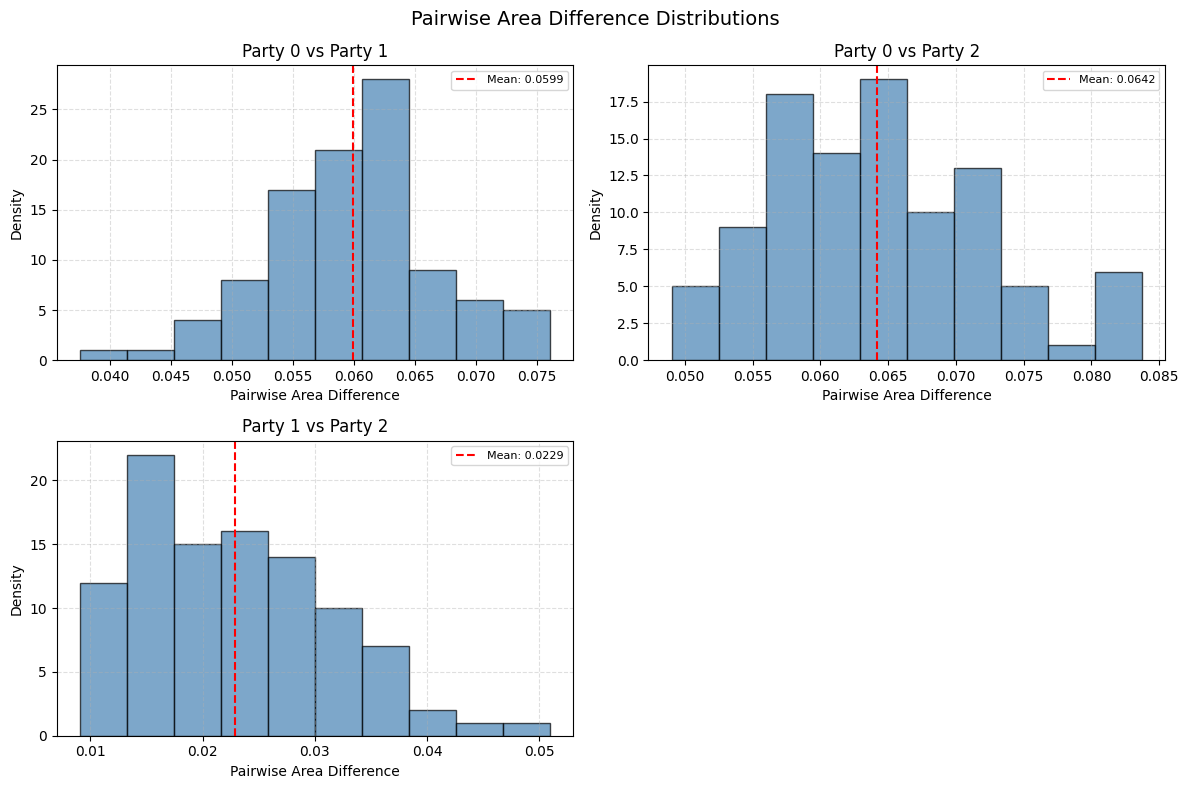

In [275]:
# ------------------------------------------------------------
# PAIRWISE AREA DIFFERENCE TABLE
# ------------------------------------------------------------
import math
import itertools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
party_pairs = list(itertools.combinations(PARTY_IDS, 2))
pairwise_matrix = []
pair_labels = []

for p1, p2 in party_pairs:
    pair_label = f"{p1} vs {p2}"
    pair_labels.append(pair_label)
    pair_row = []
    for run_idx in range(len(all_area_results)):
        area = compute_pairwise_area(
            all_step_curves[run_idx][p1],
            all_step_curves[run_idx][p2],
            NUM_DISTRICTS
        )
        pair_row.append(area)
    pairwise_matrix.append(pair_row)

df_pairwise = pd.DataFrame(
    pairwise_matrix,
    columns=[f"Run {i+1}" for i in range(len(all_area_results))]
)
df_pairwise["Mean"] = df_pairwise.mean(axis=1)
df_pairwise["Std Dev"] = df_pairwise.std(axis=1)
df_pairwise.insert(0, "Comparison", pair_labels)

print("\n--- PAIRWISE AREA DIFFERENCES ---")
print(df_pairwise.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# ------------------------------------------------------------
# PAIRWISE HISTOGRAM
# ------------------------------------------------------------

n_pairs = len(party_pairs)
n_cols = 2
n_rows = math.ceil(n_pairs / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = np.array(axes).flatten()

for i, (p1, p2) in enumerate(party_pairs):
    data = list(df_pairwise.iloc[i, 1:len(all_area_results)+1])
    mean_val = np.mean(data)

    axes[i].hist(data, bins=min(10, len(data)), alpha=0.7,
                 color='steelblue', edgecolor='black', density=False)
    axes[i].axvline(mean_val, color='red', linestyle='--',
                    linewidth=1.5, label=f"Mean: {mean_val:.4f}")
    axes[i].set_title(f"{p1} vs {p2}", fontsize=12)
    axes[i].set_xlabel("Pairwise Area Difference")
    axes[i].set_ylabel("Density")
    axes[i].legend(fontsize=8)
    axes[i].grid(True, linestyle="--", alpha=0.4)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Pairwise Area Difference Distributions", fontsize=14)
plt.tight_layout()
plt.show()

In [276]:
def print_election_results(all_district_counts, all_pr_vote_shares, all_pr_seat_shares, PARTY_IDS, NUM_DISTRICTS):
    """
    Prints a detailed election breakdown for each run including:
      - District-level vote counts and winner
      - Total seats won per party
      - Statewide vote share per party
    """
    for run_idx, district_counts in enumerate(all_district_counts):
        print(f"\n{'='*60}")
        print(f"  RUN {run_idx + 1}")
        print(f"{'='*60}")

        # District breakdown
        print(f"\n  {'District':<12} {'Winner':<12}", end="")
        for party in PARTY_IDS:
            print(f" {party:>12}", end="")
        print(f" {'Total':>10}")
        print(f"  {'-'*12} {'-'*12}", end="")
        for _ in PARTY_IDS:
            print(f" {'-'*12}", end="")
        print(f" {'-'*10}")

        for d_idx, counts in enumerate(district_counts):
            winner = max(counts, key=counts.get)
            total = sum(counts.values())
            print(f"  {'District '+str(d_idx+1):<12} {winner:<12}", end="")
            for party in PARTY_IDS:
                print(f" {counts[party]:>12}", end="")
            print(f" {total:>10}")

        # Seats won per party
        seats = {party: 0 for party in PARTY_IDS}
        for counts in district_counts:
            winner = max(counts, key=counts.get)
            seats[winner] += 1

        print(f"\n  {'--- Seats Won ---'}")
        for party in PARTY_IDS:
            bar = "█" * seats[party]
            print(f"  {party:<12}: {seats[party]:>2} seats  {bar}")

        # Statewide vote share
        print(f"\n  {'--- Statewide Vote Share ---'}")
        for party in PARTY_IDS:
            vote_share = all_pr_vote_shares[run_idx][party]
            seat_share = all_pr_seat_shares[run_idx][party]
            print(f"  {party:<12}: Vote {vote_share:.3f}  |  Seat Share {seat_share:.3f}")

    print(f"\n{'='*60}")
    print("  END OF RESULTS")
    print(f"{'='*60}\n")


# ── USAGE — call this after the simulation loop ──
print_election_results(all_district_counts, all_pr_vote_shares, all_pr_seat_shares, PARTY_IDS, NUM_DISTRICTS)


  RUN 1

  District     Winner            Party 0      Party 1      Party 2      Total
  ------------ ------------ ------------ ------------ ------------ ----------
  District 1   Party 0               175          114           69        358
  District 2   Party 0               139           98           75        312
  District 3   Party 0               123          102           87        312
  District 4   Party 0               163           99           74        336
  District 5   Party 0               152          110           70        332
  District 6   Party 0               142          105           83        330
  District 7   Party 0               157           85          116        358
  District 8   Party 0                80           37           45        162

  --- Seats Won ---
  Party 0     :  8 seats  ████████
  Party 1     :  0 seats  
  Party 2     :  0 seats  

  --- Statewide Vote Share ---
  Party 0     : Vote 0.452  |  Seat Share 1.000
  Party 1     : Vote

In [277]:
# ------------------------------------------------------------
# MULTI-PARTY EFFICIENCY GAP — SUM OF SQUARED DIFFERENCES
# ------------------------------------------------------------

gap_rows = []

for run_idx in range(len(all_district_counts)):
    district_counts = all_district_counts[run_idx]

    wasted_votes = {party: 0 for party in PARTY_IDS}
    total_votes = 0

    for district in district_counts:
        district_total = sum(district.values())
        total_votes += district_total

        sorted_parties = sorted(district.items(), key=lambda x: x[1], reverse=True)
        winner, winner_votes = sorted_parties[0]
        runner_up_votes = sorted_parties[1][1] if len(sorted_parties) > 1 else 0
        needed_to_win = runner_up_votes + 1

        for party in PARTY_IDS:
            votes = district[party]
            if party == winner:
                wasted = max(0, votes - needed_to_win)
            else:
                wasted = votes
            wasted_votes[party] += wasted

    # Compute efficiency gap as sum of (wasted_a - wasted_b)^2 
    # for all unique pairs, divided by total votes
    squared_diff_sum = 0.0
    for p1, p2 in itertools.combinations(PARTY_IDS, 2):
        squared_diff_sum += (wasted_votes[p1] - wasted_votes[p2]) ** 2

    efficiency_gap_value = squared_diff_sum / total_votes**2

    gap_rows.append({
        "Run": run_idx + 1,
        "Efficiency_Gap": efficiency_gap_value,
        **{f"{party}_Wasted": wasted_votes[party] for party in PARTY_IDS}
    })

df_gap = pd.DataFrame(gap_rows)

print("\n--- EFFICIENCY GAP (SUM OF SQUARED WASTED VOTE DIFFERENCES) ---")
print(df_gap.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

print(f"\nMean Efficiency Gap: {df_gap['Efficiency_Gap'].mean():.4f}")
print(f"Std  Efficiency Gap: {df_gap['Efficiency_Gap'].std():.4f}")


--- EFFICIENCY GAP (SUM OF SQUARED WASTED VOTE DIFFERENCES) ---
 Run  Efficiency_Gap  Party 0_Wasted  Party 1_Wasted  Party 2_Wasted
   1          0.0434             334             750             619
   2          0.0233             410             715             619
   3          0.0410             345             750             619
   4          0.0376             361             750             619
   5          0.0376             361             750             619
   6          0.0354             372             750             619
   7          0.0399             350             750             619
   8          0.0389             355             750             619
   9          0.0356             371             750             619
  10          0.0382             358             750             619
  11          0.0384             357             750             619
  12          0.0391             354             750             619
  13          0.0384             357  

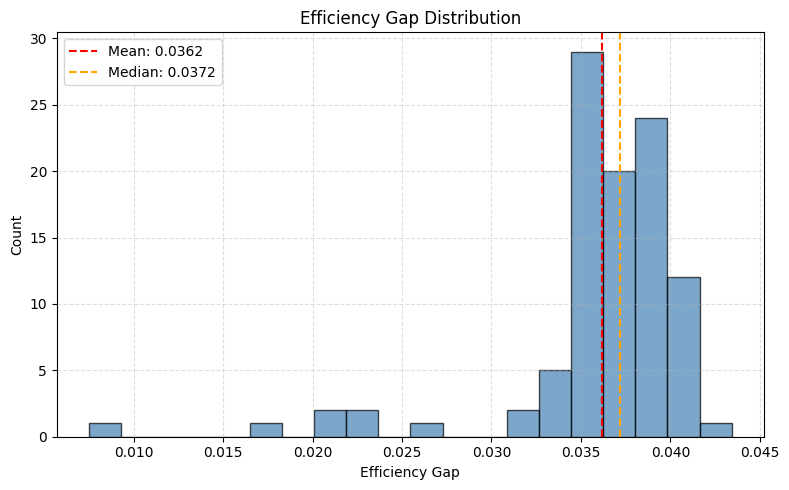

In [278]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8, 5))
plt.hist(df_gap["Efficiency_Gap"], bins="auto", color="steelblue", edgecolor="black", alpha=0.7),
  
plt.axvline(df_gap["Efficiency_Gap"].mean(), color="red", linestyle="--",
        linewidth=1.5, label=f"Mean: {df_gap['Efficiency_Gap'].mean():.4f}")
plt.axvline(df_gap["Efficiency_Gap"].median(), color="orange", linestyle="--",
            linewidth=1.5, label=f"Median: {df_gap['Efficiency_Gap'].median():.4f}")
plt.xlabel("Efficiency Gap")
plt.ylabel("Count")
axes[i].set_xlim(0, 0.15)  # ── consistent across all simulations
plt.title("Efficiency Gap Distribution")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

In [281]:
print(f"SPATIAL_INFLUENCE: {SPATIAL_INFLUENCE}")
print(f"SPATIAL_ITERATIONS: {SPATIAL_ITERATIONS}")
print(f"SPATIAL_K_NEIGHBORS: {SPATIAL_K_NEIGHBORS}")
print(f"PARTY_BIAS: {PARTY_BIAS}")
print(f"np.random.seed: check if seed(1) is still set")

print("\nParty distribution by map quadrant:")
for qx, qy, label in [(0, 0, "Bottom-Left"), (1, 0, "Bottom-Right"), 
                       (0, 1, "Top-Left"), (1, 1, "Top-Right")]:
    mask = ((voters[:, 0] > qx * WIDTH/2) & (voters[:, 0] <= (qx+1) * WIDTH/2) &
            (voters[:, 1] > qy * HEIGHT/2) & (voters[:, 1] <= (qy+1) * HEIGHT/2))
    quadrant_parties = voter_parties[mask]
    counts = np.bincount(quadrant_parties, minlength=NUM_PARTIES)
    print(f"  {label}: {[f'P{i}:{c}' for i, c in enumerate(counts)]}")


print(type(adjacency))  # should be <class 'dict'>
print(len(adjacency))   # should be NUM_VOTERS

SPATIAL_INFLUENCE: 0.85
SPATIAL_ITERATIONS: 20
SPATIAL_K_NEIGHBORS: 15
PARTY_BIAS: [0.45, 0.3, 0.25]
np.random.seed: check if seed(1) is still set

Party distribution by map quadrant:
  Bottom-Left: ['P0:122', 'P1:84', 'P2:74']
  Bottom-Right: ['P0:862', 'P1:603', 'P2:477']
  Top-Left: ['P0:53', 'P1:28', 'P2:26']
  Top-Right: ['P0:86', 'P1:30', 'P2:39']
<class 'dict'>
2500


In [283]:
for run_idx in range(min(100, len(all_district_counts))):
    dc = all_district_counts[run_idx]
    seats = {party: 0 for party in PARTY_IDS}
    for d in dc:
        winner = max(d, key=d.get)
        seats[winner] += 1
    print(f"Run {run_idx+1}: {seats}")

Run 1: {'Party 0': 8, 'Party 1': 0, 'Party 2': 0}
Run 2: {'Party 0': 7, 'Party 1': 1, 'Party 2': 0}
Run 3: {'Party 0': 8, 'Party 1': 0, 'Party 2': 0}
Run 4: {'Party 0': 8, 'Party 1': 0, 'Party 2': 0}
Run 5: {'Party 0': 8, 'Party 1': 0, 'Party 2': 0}
Run 6: {'Party 0': 8, 'Party 1': 0, 'Party 2': 0}
Run 7: {'Party 0': 8, 'Party 1': 0, 'Party 2': 0}
Run 8: {'Party 0': 8, 'Party 1': 0, 'Party 2': 0}
Run 9: {'Party 0': 8, 'Party 1': 0, 'Party 2': 0}
Run 10: {'Party 0': 8, 'Party 1': 0, 'Party 2': 0}
Run 11: {'Party 0': 8, 'Party 1': 0, 'Party 2': 0}
Run 12: {'Party 0': 8, 'Party 1': 0, 'Party 2': 0}
Run 13: {'Party 0': 8, 'Party 1': 0, 'Party 2': 0}
Run 14: {'Party 0': 8, 'Party 1': 0, 'Party 2': 0}
Run 15: {'Party 0': 8, 'Party 1': 0, 'Party 2': 0}
Run 16: {'Party 0': 7, 'Party 1': 1, 'Party 2': 0}
Run 17: {'Party 0': 8, 'Party 1': 0, 'Party 2': 0}
Run 18: {'Party 0': 8, 'Party 1': 0, 'Party 2': 0}
Run 19: {'Party 0': 8, 'Party 1': 0, 'Party 2': 0}
Run 20: {'Party 0': 8, 'Party 1': 0, 'Pa